In [1]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [3]:
model="openai/gpt-oss-120b"
from langchain_groq import ChatGroq
llm=ChatGroq(model_name=model)
llm.invoke("hi")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "hi". Simple greeting. Should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 72, 'total_tokens': 112, 'completion_time': 0.084451546, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.015203483, 'prompt_tokens_details': None, 'queue_time': 0.454718395, 'total_time': 0.099655029}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8655ddce88', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0d76-0fbf-7363-a821-deed381fe6b0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 40, 'total_tokens': 112, 'output_token_details': {'reasoning': 22}})

In [4]:
import operator
from typing import List
from langgraph.graph.message import add_messages
from pydantic import BaseModel , Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

In [6]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [7]:

state={"messages":["hi hello how are you?"]}

call_model(state)

{'messages': [AIMessage(content="Hello! I'm doing great, thank you. How can I assist you today?", additional_kwargs={'reasoning_content': 'The user says "hi hello how are you?" It\'s a casual greeting. We respond politely. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 77, 'total_tokens': 126, 'completion_time': 0.102425159, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.02194016, 'prompt_tokens_details': None, 'queue_time': 0.279323501, 'total_time': 0.124365319}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9241e9962b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0d79-076b-7741-bf1b-f89c494e5977-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 49, 'total_tokens': 126, 'output_token_details': {'reasoning': 24}})]}

In [8]:
from langchain_core.messages import AnyMessage
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]


In [9]:
workflow=StateGraph(MessagesState)

In [10]:
workflow.add_node("mybot",call_model)

In [11]:
workflow.add_edge(START,"mybot")

In [12]:
workflow.add_edge("mybot",END)

In [13]:
app=workflow.compile()

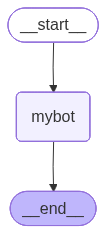

In [14]:
app

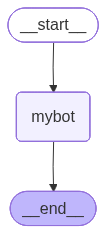

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
input={"messages":["hi hello how are you?"]}

In [17]:
app.invoke(input)

{'messages': [HumanMessage(content='hi hello how are you?', additional_kwargs={}, response_metadata={}, id='724a5138-c7fe-40d1-ac37-0ca37b113926'),
  AIMessage(content="Hello! I'm doing great, thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'We need to respond. The system says we are ChatGPT, large language model. We can answer friendly.'}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 77, 'total_tokens': 126, 'completion_time': 0.101946745, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.013588403, 'prompt_tokens_details': None, 'queue_time': 0.286066499, 'total_time': 0.115535148}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bb691ea66b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0d80-08d9-70b3-b0ea-07ef61b1674e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_token

In [19]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from mybot Node
_______
{'messages': [AIMessage(content="Hello! I'm doing great, thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'We need to respond. The system says we are ChatGPT, with no restrictions beyond the developer message. The developer says: "You are ChatGPT, a large language model trained by OpenAI." That\'s it. So we can respond normally. The user says "hi hello how are you?" We should respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 77, 'total_tokens': 168, 'completion_time': 0.191875694, 'completion_tokens_details': {'reasoning_tokens': 65}, 'prompt_time': 0.003542919, 'prompt_tokens_details': None, 'queue_time': 0.286278601, 'total_time': 0.195418613}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_f73454f048', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0d82-58ce-7153-803a-3e885c2661a2-0', 

### this is a workflow with tool calling

In [20]:
@tool
def search(query:str):
    """this is my custom tool for searching a weather"""
    if "delhi" in query.lower():
        return "the temp is 45 degree and sunny"
    return "the temp is 25 degree and cloudy"

In [21]:
search.invoke("what is a tempurature in kashmir?")

'the temp is 25 degree and cloudy'

In [22]:
llm.invoke("what is a weather in delhi?")

AIMessage(content='I don’t have access to real‑time data, so I can’t tell you the exact weather conditions in Delhi right now. For the most up‑to‑date forecast, you can check a reliable weather service such as:\n\n- **Weather.com** (https://weather.com)\n- **AccuWeather** (https://accuweather.com)\n- **India Meteorological Department (IMD)** (https://mausam.imd.gov.in)\n- A weather app on your smartphone (e.g., the built‑in iOS Weather app, Google Weather, etc.)\n\nThese sources will give you current temperature, humidity, wind speed, precipitation chances, air quality index, and any weather alerts for Delhi.  \n\nIf you’re interested in typical climate patterns for this time of year, here’s a quick overview:\n\n| Month | Avg High (°C) | Avg Low (°C) | Typical Conditions |\n|-------|---------------|--------------|--------------------|\n| Jan   | 21            | 7            | Cool, dry, occasional fog |\n| Feb   | 23            | 9            | Warm, dry |\n| Mar   | 30            | 14

### Binding a tool to the LLM

### Special Note: use some good for agentic workflow since opensource model might not give you the correct output

In [23]:
tools=[search]

In [24]:
llm_with_tool=llm.bind_tools(tools)

In [25]:
response=llm_with_tool.invoke("what is a weather is delhi?")
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is a weather is delhi?" Likely they want current weather in Delhi. Use the search tool.', 'tool_calls': [{'id': 'fc_7d52e8b4-62c2-4a1e-be76-61d2785d647f', 'function': {'arguments': '{"query":"current weather Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 130, 'total_tokens': 186, 'completion_time': 0.117580476, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.005371516, 'prompt_tokens_details': None, 'queue_time': 0.285546566, 'total_time': 0.122951992}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_49bfac06f1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0d84-bdda-7af3-a480-8dd84f36fae4-0', tool_calls=[{'name': 'search', 'args': {'query': 'current weather Delhi'}, 'id': 'fc_7d52e8b4-62c2-4a1e-be76-61d2785d6

In [26]:
response.content

''

In [27]:
response.tool_calls

[{'name': 'search',
  'args': {'query': 'current weather Delhi'},
  'id': 'fc_7d52e8b4-62c2-4a1e-be76-61d2785d647f',
  'type': 'tool_call'}]

In [28]:
def router_function(state:MessagesState):
    message=state["messages"]
    last_message=message[-1]
    if last_message.tool_calls:
        return "tools"
    return END
    

In [29]:
tools

[StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000002D1571024B0>)]

In [30]:

tool_node=ToolNode(tools)

In [31]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'search': StructuredTool(name='search', description='this is my custom tool for searching a weather', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000002D1571024B0>)}, _injected_args={'search': _InjectedArgs(state={}, store=None, runtime=None, all_injected_keys=set(), _optional_state_args=set())}, _handle_tool_errors=<function _default_handle_tool_errors at 0x000002D1570B7AB0>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)

In [32]:
workflow2=StateGraph(MessagesState)

In [33]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm_with_tool.invoke(messages)
    return {"messages": [response]}

In [34]:
workflow2.add_node("llmwithtool",call_model)

workflow2.add_node("mytools",tool_node)

workflow2.add_edge(START,"llmwithtool")

workflow2.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})


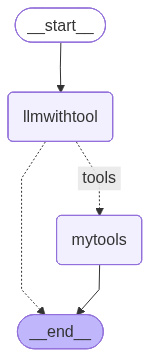

In [36]:
app2=workflow2.compile()

app2

In [37]:
response=app2.invoke({"messages":["what is a weather in bengaluru?"]})

In [38]:
response["messages"][-1].content

'the temp is 25 degree and cloudy'

In [39]:
app2.invoke({"messages":["what is a weather in delhi?"]})   # Autogen- reflect_on_tool_use = False

{'messages': [HumanMessage(content='what is a weather in delhi?', additional_kwargs={}, response_metadata={}, id='6576afdf-8b52-4473-8dd5-70cc3b900c3f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "what is a weather in delhi?" Likely they want current weather. Use the search tool. Probably query "Delhi weather".', 'tool_calls': [{'id': 'fc_39296fe8-0165-4e2f-8d89-056eca5b94a2', 'function': {'arguments': '{"query":"Delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 130, 'total_tokens': 188, 'completion_time': 0.122081448, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.005154675, 'prompt_tokens_details': None, 'queue_time': 0.158771624, 'total_time': 0.127236123}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5a93aea882', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, i

In [40]:
workflow2.add_edge("mytools","llmwithtool")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


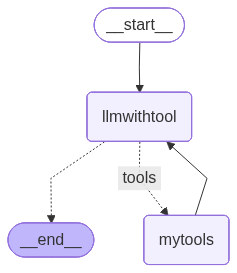

In [42]:
app2=workflow2.compile() #Autogen - reflect_on_tool_use = True

app2

In [44]:
for output in app2.stream({"messages":["what is a weather in new delhi?"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")
    

here is output from llmwithtool
_______
{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "what is a weather in new delhi?" Likely they want current weather. Use the search tool.', 'tool_calls': [{'id': 'fc_41f0a660-8080-4c92-938c-dbd321573c19', 'function': {'arguments': '{"query":"current weather New Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 131, 'total_tokens': 186, 'completion_time': 0.113275599, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.005410244, 'prompt_tokens_details': None, 'queue_time': 0.285738508, 'total_time': 0.118685843}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_3af2d41834', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0d8c-4414-7a30-9652-cd116182b7df-0', tool_calls=[{'name': 'search', 'args': {'query': 'current weather New

In [45]:
for output in app2.stream({"messages":["which city has 45 degree celcius"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")
    

here is output from llmwithtool
_______
{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "which city has 45 degree celcius". Likely they want to know which city currently has temperature 45°C. Need to use search tool to get current weather. Query could be "city temperature 45°C". Might need to find a city currently at 45°C. Use search.', 'tool_calls': [{'id': 'fc_44dee562-58a7-4247-bcff-687182e36371', 'function': {'arguments': '{"query":"city currently 45°C temperature"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 130, 'total_tokens': 225, 'completion_time': 0.19708776, 'completion_tokens_details': {'reasoning_tokens': 64}, 'prompt_time': 0.009576983, 'prompt_tokens_details': None, 'queue_time': 0.308677377, 'total_time': 0.206664743}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c800245357', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'l

### Adding Memory with Checkpointings

The power of Langgraph really shines when we add ** persistant memory**. This allows our agent to :

- Remember conversations accross multiple interactios
- Resume from where it left off
- Handle long-running workflow
- support Human-in-loop


### What is checkpointing

**Checkpointing** automatically saves the state after each steps. when you invoke the graph again with the same 'thread_id'. it load the saved state and continue from there 

Think of it like a video game save system!!



In [46]:
from langgraph.checkpoint.memory import MemorySaver

In [47]:
memory=MemorySaver()

In [48]:
workflow3=StateGraph(MessagesState)

workflow3.add_node("llmwithtool",call_model)

workflow3.add_node("mytools",tool_node)

workflow3.add_edge(START,"llmwithtool")

workflow3.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})

workflow3.add_edge("mytools","llmwithtool")

In [49]:
app4=workflow3.compile(checkpointer=memory)

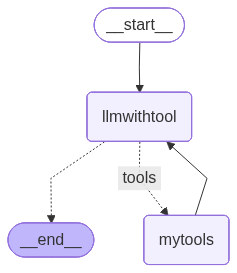

In [50]:
app4

In [51]:
config={"configurable": {"thread_id": "1afnjncj"}}

In [52]:
events=app4.stream(
    {"messages":["what is a weather in new delhi?"]},config=config,stream_mode="values"
    )

In [53]:
for event in events:
    event["messages"][-1].pretty_print()
    

================================ Human Message =================================

what is a weather in new delhi?
================================== Ai Message ==================================
Tool Calls:
  search (fc_999746ba-3963-4381-adfd-2d662ed43af3)
 Call ID: fc_999746ba-3963-4381-adfd-2d662ed43af3
  Args:
    query: current weather New Delhi
================================= Tool Message =================================
Name: search

the temp is 45 degree and sunny
================================== Ai Message ==================================

The current weather in New Delhi is **hot and sunny**, with the temperature around **45 °C (113 °F)**. 🌞

Stay hydrated and try to avoid prolonged exposure to the sun if you’re out and about! If you need a forecast for the next few days or any other details, just let me know.


In [54]:
events=app4.stream(
    {"messages":["what is a weather in indore?"]},config=config,stream_mode="values"
    )
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is a weather in indore?
================================== Ai Message ==================================
Tool Calls:
  search (fc_b5db04f1-8cf0-4a8e-a622-b40a672e9efe)
 Call ID: fc_b5db04f1-8cf0-4a8e-a622-b40a672e9efe
  Args:
    query: current weather Indore
================================= Tool Message =================================
Name: search

the temp is 25 degree and cloudy
================================== Ai Message ==================================

The current weather in **Indore** is **cloudy**, with the temperature around **25 °C (77 °F)**. 🌥️

If you’d like a longer‑term forecast or any other details, just let me know!


In [55]:
config

{'configurable': {'thread_id': '1afnjncj'}}

In [56]:
memory.get(config)

{'v': 4,
 'ts': '2026-06-28T09:31:03.745372+00:00',
 'id': '1f172d41-513e-64a7-8008-535c0349541c',
 'channel_versions': {'__start__': '00000000000000000000000000000007.0.7235058547083508',
  'messages': '00000000000000000000000000000010.0.8543906084102875',
  'branch:to:llmwithtool': '00000000000000000000000000000010.0.8543906084102875',
  'branch:to:mytools': '00000000000000000000000000000009.0.8633986280466389'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000006.0.45767322609028427'},
  'llmwithtool': {'branch:to:llmwithtool': '00000000000000000000000000000009.0.8633986280466389'},
  'mytools': {'branch:to:mytools': '00000000000000000000000000000008.0.8295519961528598'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='what is a weather in new delhi?', additional_kwargs={}, response_metadata={}, id='b2c97ea0-c710-4186-8adb-a2073a321809'),
   AIMessage(content='', additional_kwargs={'reasoning_c

In [57]:
events=app4.stream(
    {"messages":["in which city the temp was 25 degree?"]},config=config,stream_mode="values"
    )

In [58]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

in which city the temp was 25 degree?
================================== Ai Message ==================================

The temperature of **25 °C** was reported for **Indore**.
